In [22]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import pandas as pd
import h5py
import pickle 
import numpy as np 
import pyBigWig
from helpers import * 
from kerasAC.helpers.format_interpretations import * 
from sklearn.metrics import average_precision_score

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
chrom="chr1"
cell_line="K562"
fold="0"

In [24]:
vierstra=get_motif_offsets_for_peaks("/srv/scratch/annashch/chrombpnet/accuracy_footprint_compare/vierstra_idr_intersections/"+cell_line+".vierstra.idr.intersections.bed",'chr1')

In [4]:
list(vierstra.keys())[0:10]

[('chr1', 629729),
 ('chr1', 629555),
 ('chr1', 630274),
 ('chr1', 630403),
 ('chr1', 630886),
 ('chr1', 634300),
 ('chr1', 634177),
 ('chr1', 634042),
 ('chr1', 634557),
 ('chr1', 634415)]

In [5]:
len(vierstra)

11107

In [6]:
tobias=pyBigWig.open("/oak/stanford/groups/akundaje/projects/enzymatic_bias_correction/tobias/dnase/footprints/K562_idr_footprints.bw",'r')

In [7]:
cur_shap=pickle.load(open("/srv/scratch/annashch/chrombpnet/k562_dnase/bpnet/interpret/K562.DNASE.bias_corrected_bpnet_tobias.fold0.deepSHAP",'rb'))


In [8]:
cur_shap.keys()

dict_keys(['label_prof', 'label_sum', 'pred_prof', 'pred_sum', 'profile_shap', 'count_shap', 'seq'])

In [9]:
class_shap=format_binary_deepshap("/srv/scratch/annashch/bias_correction/uncorrected/classification/K562/interpretation/DNASE.K562.0.deepSHAP.interp.npz",
                                  "chr1")    


In [10]:
reg_shap=format_binary_deepshap("/srv/scratch/annashch/bias_correction/uncorrected/regression/K562/interpretation/DNASE.K562.0.deepSHAP.interp.npz",
                               "chr1")


In [11]:
gkm_scores=format_gkm_scores("/oak/stanford/groups/akundaje/projects/enzymatic_bias_correction/svm/aggregate/gkmexplain.K562.0.txt",
                            "chr1")


In [12]:
cur_index=12

findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.
findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


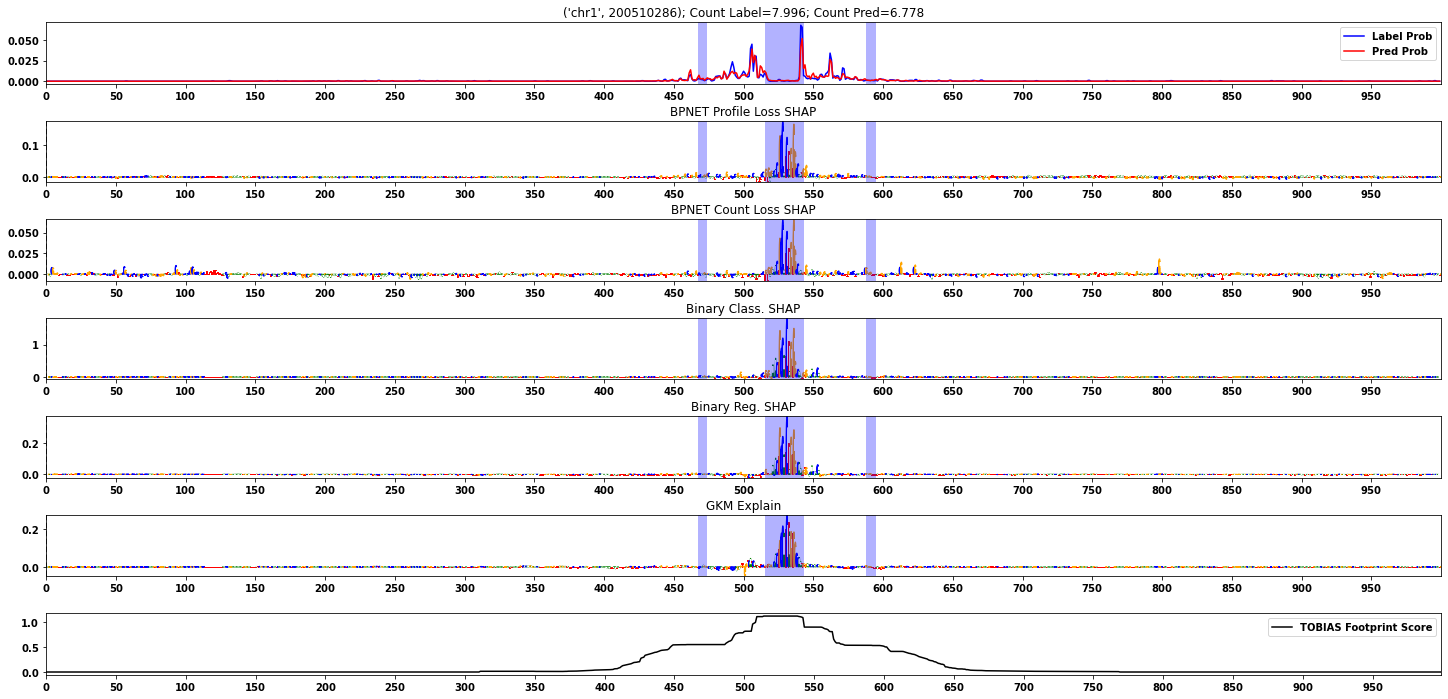

In [25]:
coord=list(gkm_scores.keys())[cur_index]

#get the tobias footprint scores 
tobias_vals=np.nan_to_num(tobias.values(coord[0],coord[1]-500,coord[1]+500))

#get the bpnet profile & count shap values 
label_prob, label_sum, pred_prob, pred_sum, profile_shap, count_shap, seq, minval_perf, maxval_perf, minval_shap, maxval_shap=extract_region(coord,cur_shap)
profile_shap.shape

#classification shap 
binary_class_shap=class_shap[coord]
binary_class_shap.shape

#regression shap 
binary_reg_shap=reg_shap[coord]
binary_reg_shap.shape

#gkm explain score 
gkm_score=gkm_scores[coord]
gkm_score.shape

motif_coords=vierstra[coord]

#get min/max shap scores 
minval=min([profile_shap.min(),count_shap.min(),binary_class_shap.min(),binary_reg_shap.min(),gkm_score.min()])
maxval=max([profile_shap.max(),count_shap.max(),binary_class_shap.max(),binary_reg_shap.max(),gkm_score.max()])


make_plot(coord,
          tobias_vals,
          label_prob,
          pred_prob,
          profile_shap,
          count_shap,
          label_sum,
          pred_sum,
          seq,
          binary_class_shap,
          binary_reg_shap,
          gkm_score,
          xmin=0,
          xmax=1000,
          motif_coords=motif_coords)

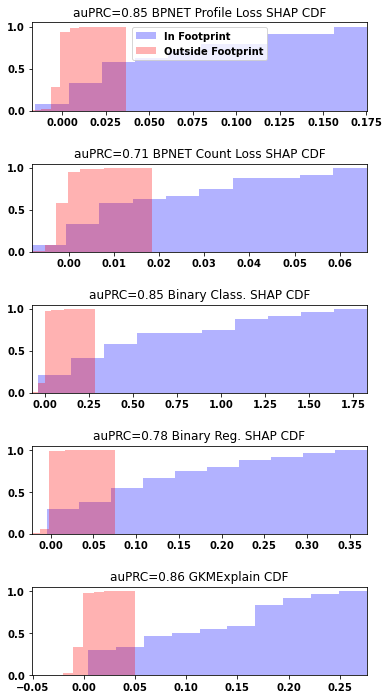

In [26]:
true_vals=get_true_pos(tobias_vals,motif_coords)
if true_vals is not None:
    make_plot_perf(profile_shap,
              count_shap,
              binary_class_shap,
              binary_reg_shap,
              gkm_score,
              seq,
              true_vals)


In [15]:
#smoothing for fimo

200509786

In [27]:
smooth(project(profile_shap,seq))

NameError: name 'project' is not defined